In [1]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.utils import plot_model, to_categorical
from keras.datasets import mnist
import cv2
import matplotlib.pyplot as plt

In [2]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
x_test.shape

(10000, 28, 28)

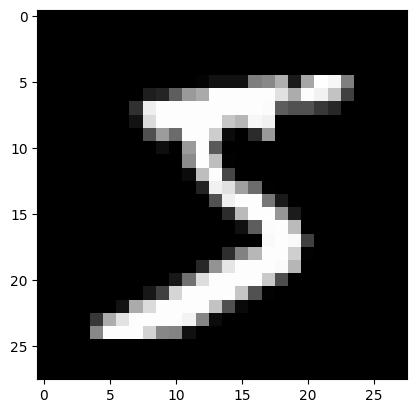

In [5]:
plt.imshow(x_train[0],cmap='gray')

In [6]:
y_train[0]

np.uint8(5)

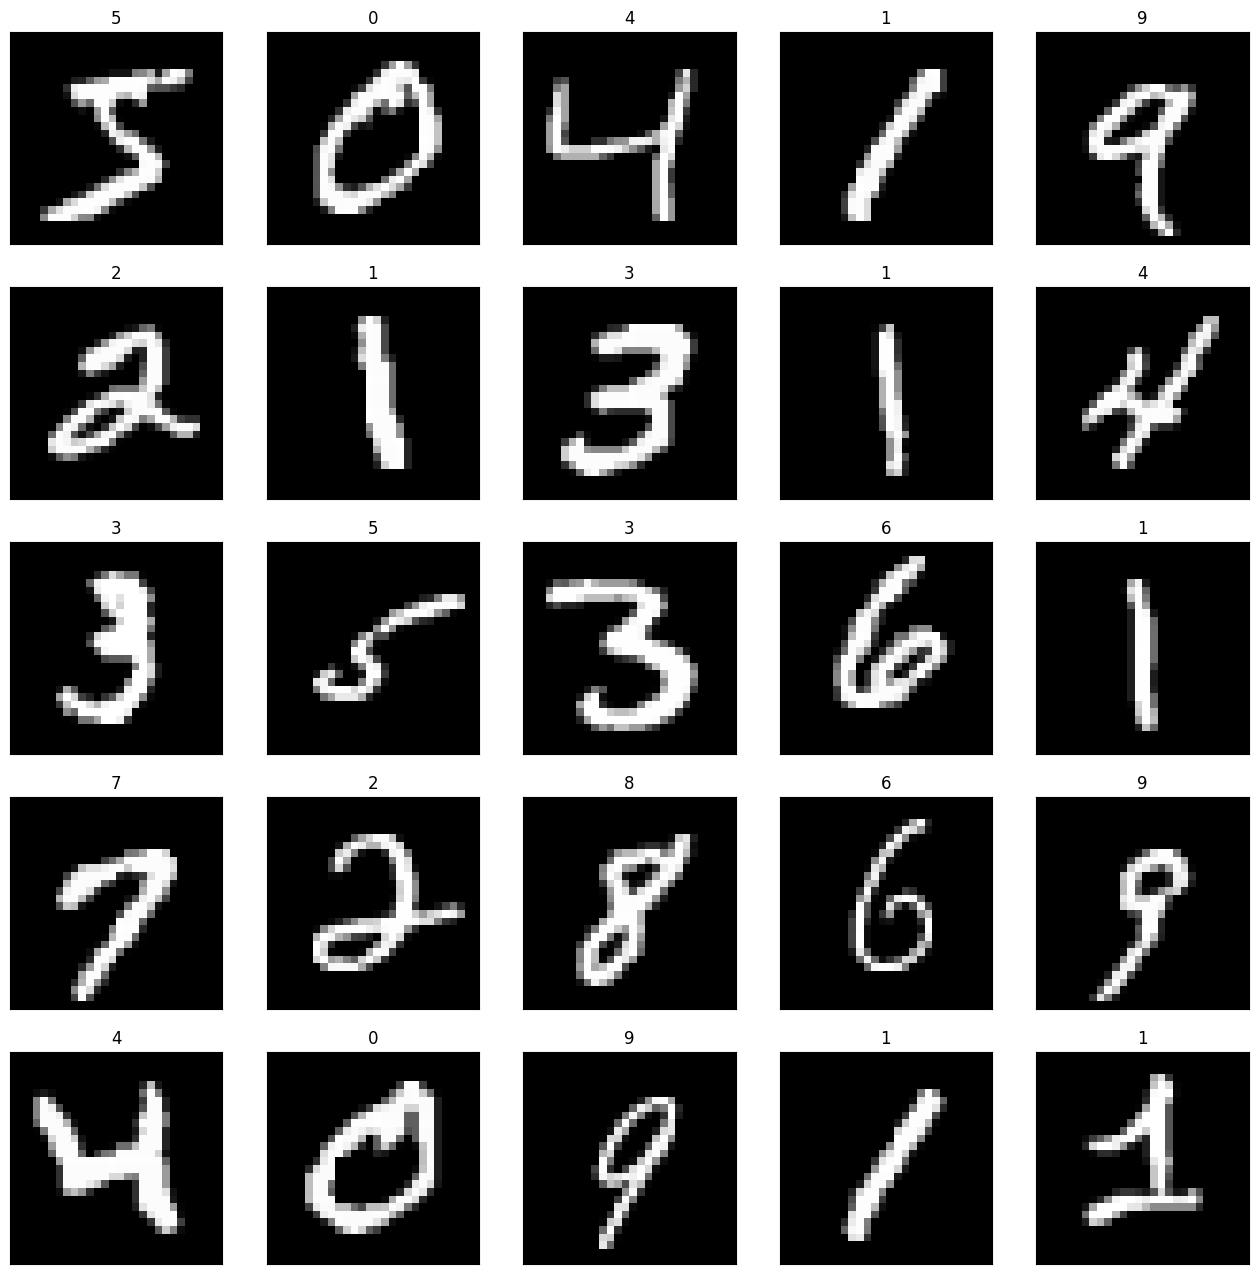

In [7]:
plt.figure(figsize=(16,16))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i],cmap='gray')
    plt.title(y_train[i])
    plt.xticks([]);
    plt.yticks([])

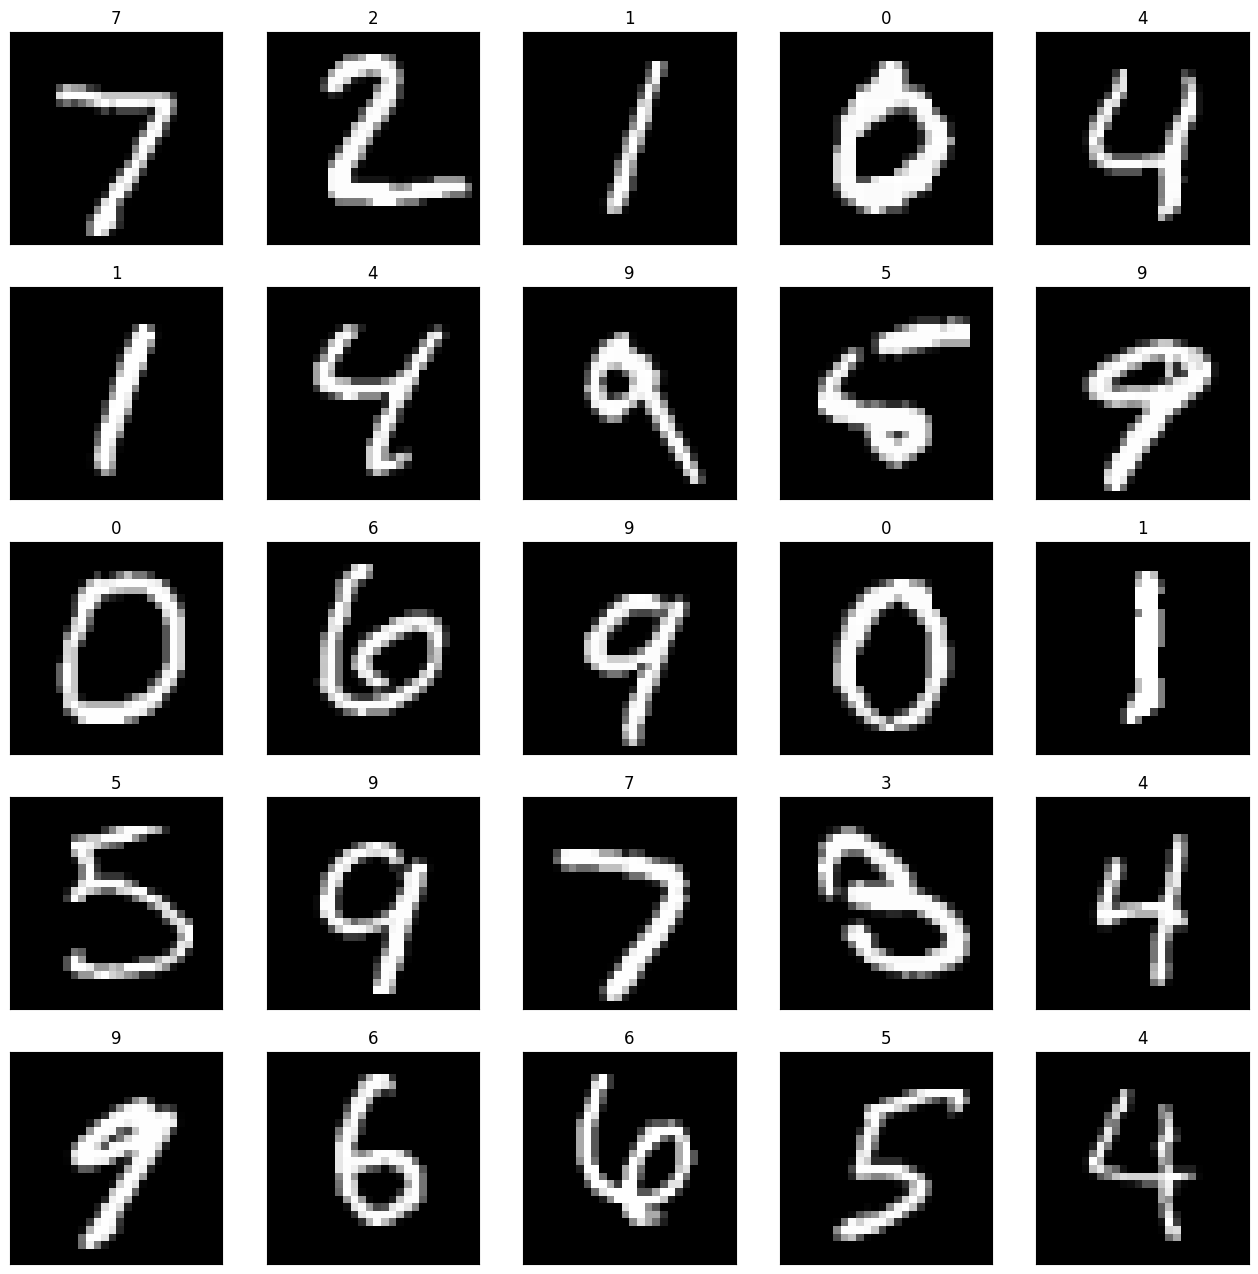

In [8]:
plt.figure(figsize=(16,16))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[i],cmap='gray')
    plt.title(y_test[i])
    plt.xticks([]);
    plt.yticks([])

In [9]:
import seaborn as sns

<Axes: xlabel='count'>

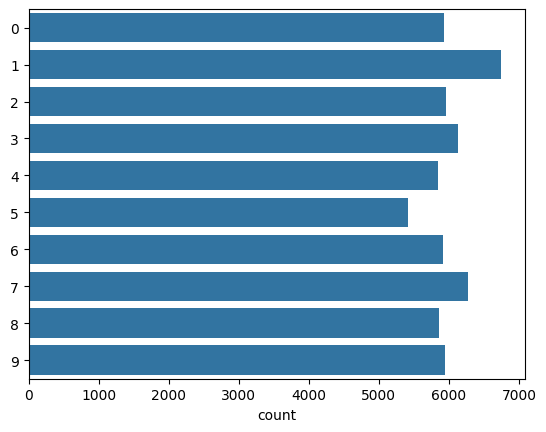

In [10]:
sns.countplot(y=y_train)

# Normalize

In [11]:
x_train=x_train/255
x_test=x_test/255

In [12]:
x_train[0].shape

(28, 28)

In [13]:
x_train[0].shape

(28, 28)

In [14]:
x_train=x_train.reshape(-1,x_train[0].size)

In [15]:
x_train.shape

(60000, 784)

In [16]:
x_test=x_test.reshape(-1, x_train[0].size)

In [17]:
x_test.shape

(10000, 784)

In [18]:
y_train_new=to_categorical(y_train)
y_test_new=to_categorical(y_test)

In [19]:
y_train_new.shape

(60000, 10)

In [20]:
y_train_new

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(60000, 10))

#build the model

In [21]:
model=Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(512,activation='relu'))
model.add(Dense(256,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

In [24]:
#train the model
x_train.shape,y_train.shape

((60000, 784), (60000,))

In [25]:
history = model.fit(x_train,y_train_new,epochs=10,batch_size=10)

Epoch 1/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9423 - loss: 0.1863
Epoch 2/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9724 - loss: 0.0914
Epoch 3/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9799 - loss: 0.0670
Epoch 4/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9840 - loss: 0.0538
Epoch 5/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9870 - loss: 0.0439
Epoch 6/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9885 - loss: 0.0410
Epoch 7/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9905 - loss: 0.0327
Epoch 8/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9906 - loss: 0.0346
Epoch 9/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9919 - loss: 0.0285
Epoch 10/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9924 - loss: 0.0284


In [26]:
model.evaluate(x_test,y_test_new,batch_size=1)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.9788 - loss: 0.1401


[0.14014337956905365, 0.9787999987602234]

In [41]:
img_num=cv2.imread("D:\\AshleshaRuchika\\PGCP-AI\\NLP\\images\\new-char1.jpg",0)
img_num=cv2.resize(img_num,(28,28))
thresh,img_num=cv2.threshold(img_num,100,255,cv2.THRESH_BINARY_INV)
img_num=img_num.reshape(1,784)
pred=model.predict(img_num,verbose=False)
print(pred.argmax())

5


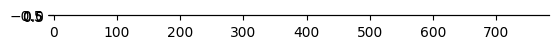

In [42]:
plt.imshow(img_num, cmap='gray')